**Project 2 - Exploratory Data Analysis (EDA)**


Superstore Sales Dataset

Objective:

To understand the Superstore dataset using statistical summaries, comparisons, outlier detection, and visualizations.


Import Libraries



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,5)

Load Dataset


In [2]:
df = pd.read_csv("Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Dataset Overview

In [3]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Rows and Columns: (9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [4]:
df.isnull().sum()


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Summary Statistics

In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


Mean, Median, Mode

In [6]:
print("Mean Sales:", df["Sales"].mean())
print("Median Sales:", df["Sales"].median())
print("Mode Category:", df["Category"].mode()[0])
print("Mode Region:", df["Region"].mode()[0])

Mean Sales: 229.85800083049833
Median Sales: 54.489999999999995
Mode Category: Office Supplies
Mode Region: West


Standard Deviation

In [7]:
print("Sales Standard Deviation:", df["Sales"].std())
print("Profit Standard Deviation:", df["Profit"].std())

Sales Standard Deviation: 623.2451005086818
Profit Standard Deviation: 234.26010769095757


Category-wise Comparison

In [8]:
category_summary = df.groupby("Category")[["Sales", "Profit"]].sum()
category_summary

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


Region-wise Comparison

In [9]:
region_summary = df.groupby("Region")[["Sales", "Profit"]].sum()
region_summary

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


Correlation Matrix

In [10]:
numeric_df = df.select_dtypes(include=["number"])
correlation = numeric_df.corr()
correlation

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
Row ID,1.000000,0.009671,-0.001359,-0.004016,0.013480,0.012497
Postal Code,0.009671,1.000000,-0.023854,0.012761,0.058443,-0.029961
Sales,-0.001359,-0.023854,1.000000,0.200795,-0.028190,0.479064
Quantity,-0.004016,0.012761,0.200795,1.000000,0.008623,0.066253
Discount,0.013480,0.058443,-0.028190,0.008623,1.000000,-0.219487
Profit,0.012497,-0.029961,0.479064,0.066253,-0.219487,1.000000


Heatmap

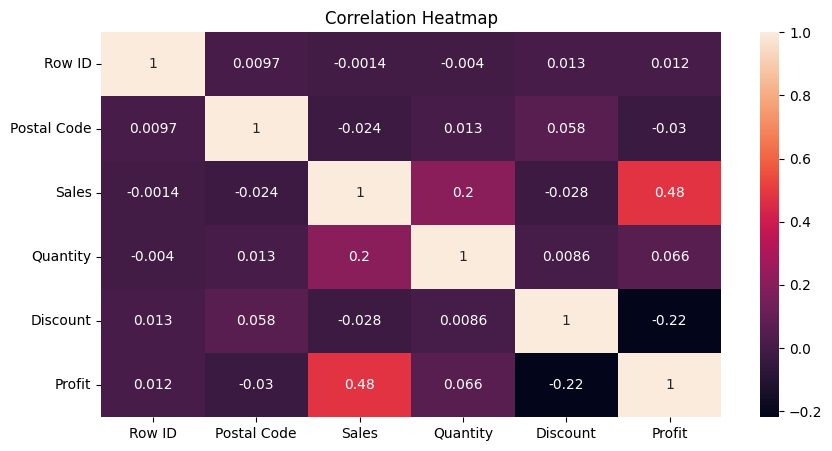

In [11]:
sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap")
plt.show()

Histogram

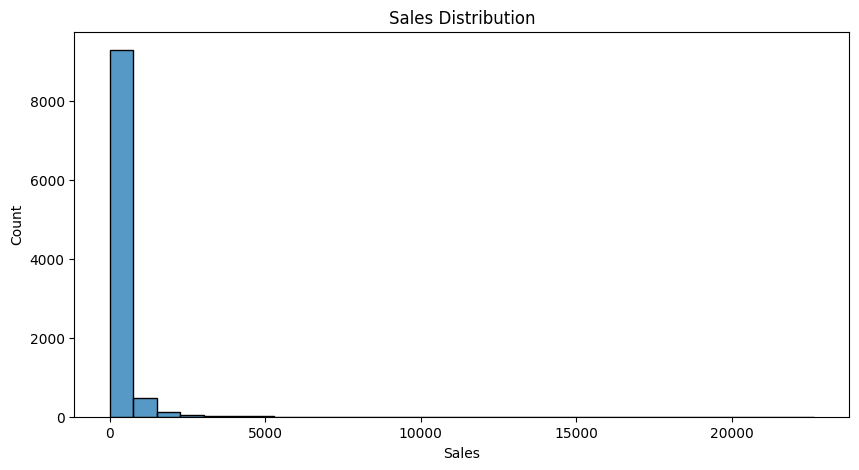

In [12]:
sns.histplot(df["Sales"], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Count")
plt.show()

Box Plot for Outliers

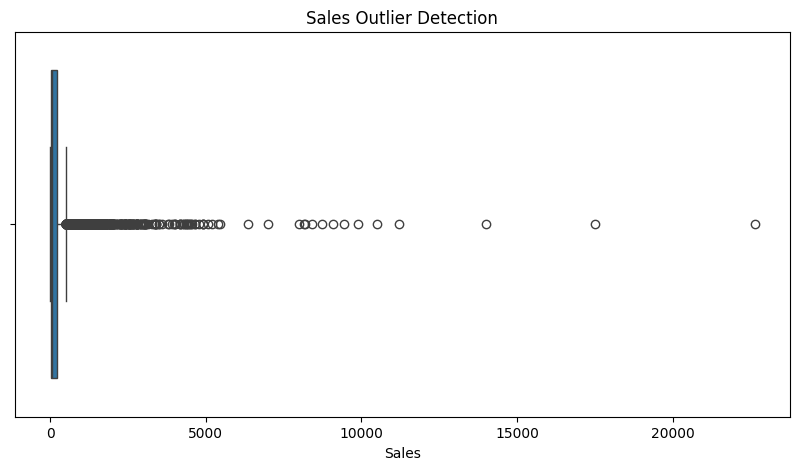

In [13]:
sns.boxplot(x=df["Sales"])
plt.title("Sales Outlier Detection")
plt.show()

Profit by Category Chart

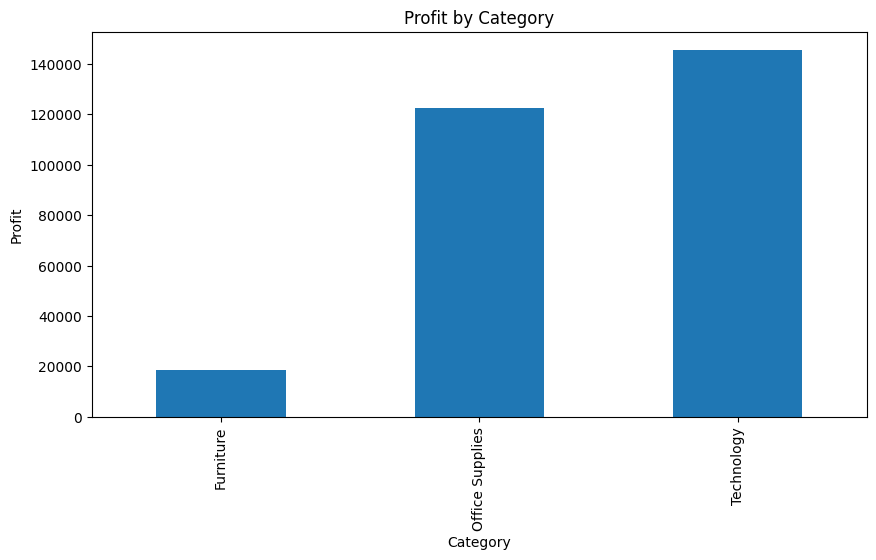

In [14]:
category_summary["Profit"].plot(kind="bar")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()


# Key Insights



1. Most sales transactions are concentrated in the lower sales range.

2. The dataset contains high-value sales outliers.

3. Category-wise analysis shows which product categories generate higher sales and profit.

4. Region-wise analysis helps identify profitable business regions.

5. Correlation analysis helps understand relationships between numerical variables.

## Conclusion

Exploratory Data Analysis helped understand the structure, distribution, relationships, and outliers in the Superstore dataset. The analysis provided useful insights into sales, profit, category performance, and regional business trends.